In [1]:
!pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = '/content/drive/MyDrive/Updated Processed Diu.csv'
df = pd.read_csv(file_path)

df.head()

,Age,Gender,University,Department,Academic_Year,Current_CGPA,waiver_or_scholarship,PSS1,PSS2,PSS3,...,PHQ2,PHQ3,PHQ4,PHQ5,PHQ6,PHQ7,PHQ8,PHQ9,Depression Value,Depression Label
0,18-22,Female,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Second Year or Equivalent,2.50 - 2.99,No,3.0,4.0,3.0,...,2.0,3.0,2.0,2.0,2.0,2.0,3.0,2.0,20.0,Severe Depression
1,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,3.0,3.0,4.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,19.0,Moderately Severe Depression
2,18-22,Male,American International University Bangladesh (...,Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No Depression
3,18-22,Male,American International University Bangladesh (...,Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,3.0,1.0,2.0,...,1.0,2.0,1.0,2.0,1.0,2.0,2.0,1.0,14.0,Moderate Depression
4,18-22,Male,North South University (NSU),Engineering - CS / CSE / CSC / Similar to CS,Second Year or Equivalent,2.50 - 2.99,No,4.0,4.0,4.0,...,3.0,3.0,3.0,1.0,3.0,0.0,3.0,3.0,20.0,Severe Depression


In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2039 entries, 0 to 2038
Data columns (total 39 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    2038 non-null   object 
 1   Gender                 2038 non-null   object 
 2   University             2038 non-null   object 
 3   Department             2038 non-null   object 
 4   Academic_Year          2038 non-null   object 
 5   Current_CGPA           2038 non-null   object 
 6   waiver_or_scholarship  2038 non-null   object 
 7   PSS1                   2038 non-null   float64
 8   PSS2                   2038 non-null   float64
 9   PSS3                   2038 non-null   float64
 10  PSS4                   2038 non-null   float64
 11  PSS5                   2038 non-null   float64
 12  PSS6                   2038 non-null   float64
 13  PSS7                   2038 non-null   float64
 14  PSS8                   2038 non-null   float64
 15  PSS9

,PSS1,PSS2,PSS3,PSS4,PSS5,PSS6,PSS7,PSS8,PSS9,PSS10,...,PHQ1,PHQ2,PHQ3,PHQ4,PHQ5,PHQ6,PHQ7,PHQ8,PHQ9,Depression Value
count,2038.000000,2038.000000,2038.000000,2038.000000,2038.000000,2038.000000,2038.000000,2038.000000,2038.000000,2038.000000,...,2038.000000,2038.000000,2038.000000,2038.000000,2038.000000,2038.000000,2038.000000,2038.000000,2038.000000,2038.000000
mean,2.348381,2.324338,2.705103,2.368499,2.174190,1.791953,1.933759,1.721295,2.424436,2.432777,...,1.461727,1.791462,1.662905,1.954367,1.498528,1.786555,1.638371,1.435721,1.172228,14.401865
std,1.178404,1.156105,1.131893,1.222891,1.085714,1.097099,1.018257,1.131878,1.176572,1.166605,...,0.954671,1.034593,1.057831,0.974076,1.043834,1.073205,1.025564,1.025708,1.141563,6.664182
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,9.000000
50%,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,1.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,1.000000,1.000000,14.000000
75%,3.000000,3.000000,4.000000,3.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,...,2.000000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,2.000000,2.000000,19.000000
max,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,27.000000


In [6]:
df = df.dropna()

In [7]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [9]:
df.columns

Index(['Age', 'Gender', 'University', 'Department', 'Academic_Year',
       'Current_CGPA', 'waiver_or_scholarship', 'PSS1', 'PSS2', 'PSS3', 'PSS4',
       'PSS5', 'PSS6', 'PSS7', 'PSS8', 'PSS9', 'PSS10', 'Stress Value',
       'Stress Label', 'GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7',
       'Anxiety Value', 'Anxiety Label', 'PHQ1', 'PHQ2', 'PHQ3', 'PHQ4',
       'PHQ5', 'PHQ6', 'PHQ7', 'PHQ8', 'PHQ9', 'Depression Value',
       'Depression Label'],
      dtype='object')

In [11]:
target_column = 'Depression Label'

X = df.drop([target_column], axis=1)
y = df[target_column]

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [14]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)
pred_lr = model_lr.predict(X_test)

In [15]:
model_dt = DecisionTreeClassifier()
model_dt.fit(X_train, y_train)
pred_dt = model_dt.predict(X_test)

In [16]:
model_rf = RandomForestClassifier(n_estimators=100)
model_rf.fit(X_train, y_train)
pred_rf = model_rf.predict(X_test)

In [17]:
model_svm = SVC()
model_svm.fit(X_train, y_train)
pred_svm = model_svm.predict(X_test)

In [18]:
model_xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
model_xgb.fit(X_train, y_train)
pred_xgb = model_xgb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:27:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [19]:
results = {
    "Logistic Regression": accuracy_score(y_test, pred_lr),
    "Decision Tree": accuracy_score(y_test, pred_dt),
    "Random Forest": accuracy_score(y_test, pred_rf),
    "SVM": accuracy_score(y_test, pred_svm),
    "XGBoost": accuracy_score(y_test, pred_xgb)
}

for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

Logistic Regression: 0.9485
Decision Tree: 1.0000
Random Forest: 0.9926
SVM: 0.8922
XGBoost: 1.0000


In [20]:
models = {
    "Logistic Regression": pred_lr,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf,
    "SVM": pred_svm,
    "XGBoost": pred_xgb
}

for name, pred in models.items():
    print(f"\n{name}")
    print(classification_report(y_test, pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        91
           1       0.80      0.63      0.71        19
           2       0.94      0.96      0.95        80
           3       0.96      0.99      0.97        97
           4       0.57      0.80      0.67         5
           5       1.00      0.97      0.99       116

    accuracy                           0.95       408
   macro avg       0.87      0.88      0.87       408
weighted avg       0.95      0.95      0.95       408


Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        91
           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00        80
           3       1.00      1.00      1.00        97
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00       116

    accuracy                           1.

In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_table = []

for name, pred in models_pred.items():
    acc = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred, average='weighted')
    recall = recall_score(y_test, pred, average='weighted')
    f1 = f1_score(y_test, pred, average='weighted')

    metrics_table.append([name, acc, precision, recall, f1])

metrics_df = pd.DataFrame(metrics_table, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score"
])

metrics_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.948529,0.949262,0.948529,0.948071
1,Decision Tree,1.000000,1.000000,1.000000,1.000000
2,Random Forest,0.992647,0.992882,0.992647,0.992392
3,SVM,0.892157,0.893902,0.892157,0.891681
4,XGBoost,1.000000,1.000000,1.000000,1.000000


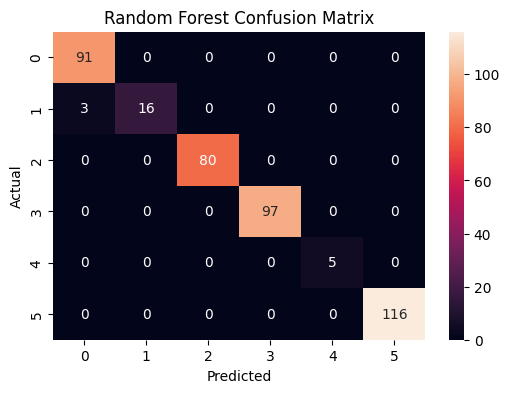

In [21]:
cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [22]:
le_target = LabelEncoder()
y_test_encoded = le_target.fit_transform(y_test)

In [23]:
probs = {
    "Logistic Regression": model_lr.predict_proba(X_test),
    "Decision Tree": model_dt.predict_proba(X_test),
    "Random Forest": model_rf.predict_proba(X_test),
    "SVM": model_svm.decision_function(X_test),
    "XGBoost": model_xgb.predict_proba(X_test)
}

In [29]:
from sklearn.metrics import roc_auc_score

for name, prob in probs.items():
    try:
        if name == "SVM":
            auc = roc_auc_score(y_test_encoded, prob, multi_class='ovr')
        else:
            auc = roc_auc_score(y_test_encoded, prob, multi_class='ovr')
        print(f"{name} AUC: {auc:.4f}")
    except:
        print(f"{name} AUC: SVM Not supported AUC")

Logistic Regression AUC: 0.9972
Decision Tree AUC: 1.0000
Random Forest AUC: 0.9999
SVM AUC: SVM Not supported AUC
XGBoost AUC: 1.0000


In [33]:
models_pred = {
    "Logistic Regression": pred_lr,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf,
    "SVM": pred_svm,
    "XGBoost": pred_xgb
}

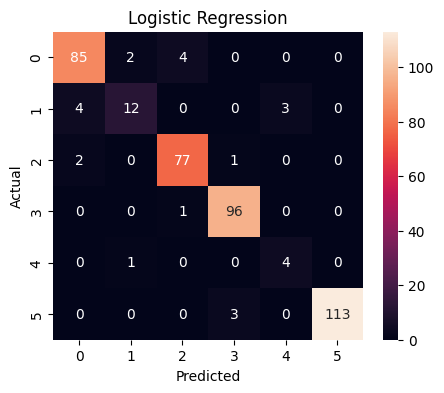

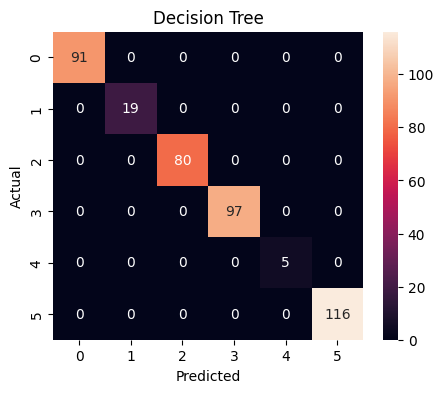

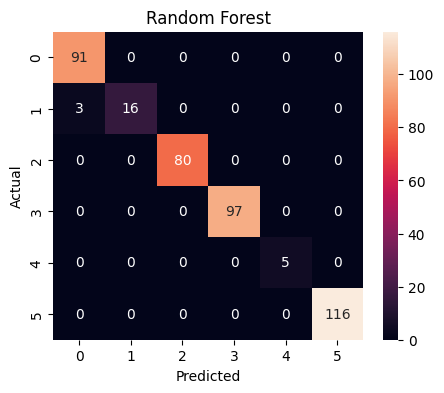

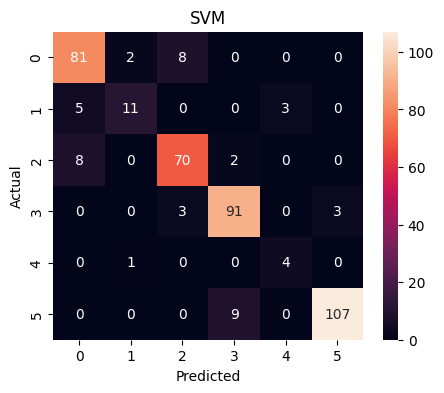

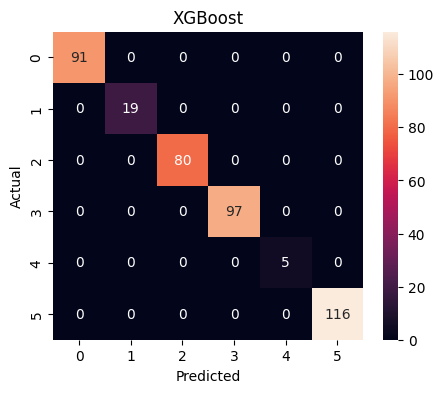

In [40]:
models_pred = {
    "Logistic Regression": pred_lr,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf,
    "SVM": pred_svm,
    "XGBoost": pred_xgb
}

for name, pred in models_pred.items():
    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(name)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

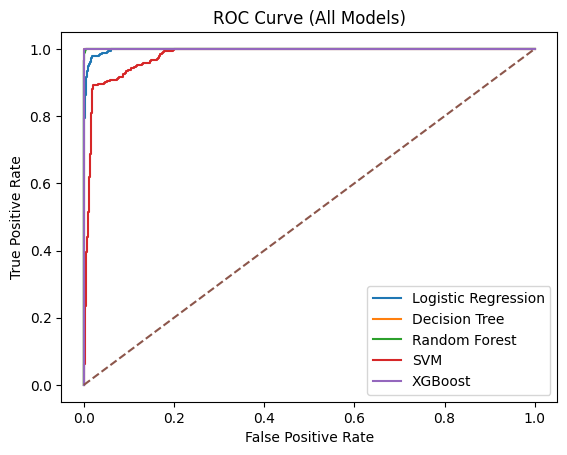

In [39]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve

n_classes = len(np.unique(y_test_encoded))
y_test_bin = label_binarize(y_test_encoded, classes=np.arange(n_classes))

plt.figure()

for name, prob in probs.items():
    try:
        if name == "SVM":
            scores = prob
        else:
            scores = prob

        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), scores.ravel())
        plt.plot(fpr, tpr, label=name)
    except:
        continue

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Models)")
plt.legend()
plt.show()

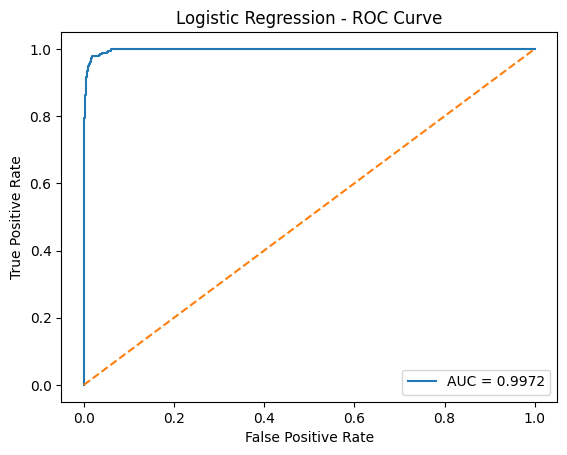

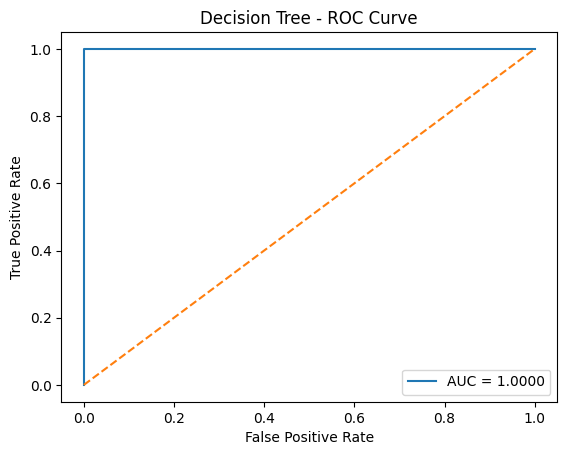

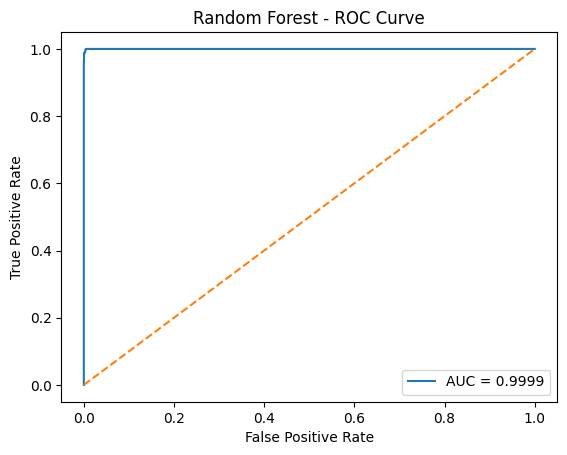

<Figure size 640x480 with 0 Axes>

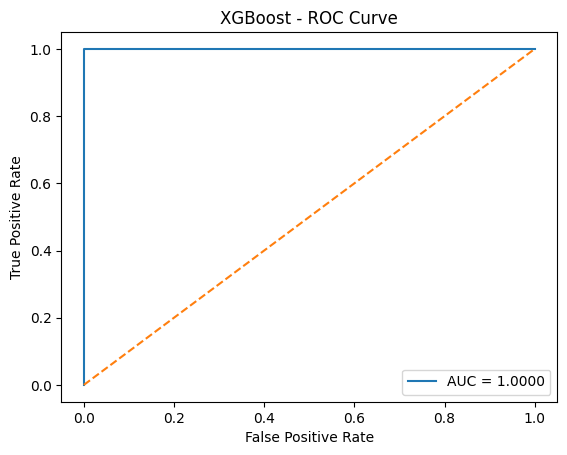

In [35]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

y_test_encoded = LabelEncoder().fit_transform(y_test)
n_classes = len(np.unique(y_test_encoded))
y_test_bin = label_binarize(y_test_encoded, classes=np.arange(n_classes))

model_probs = {
    "Logistic Regression": model_lr.predict_proba(X_test),
    "Decision Tree": model_dt.predict_proba(X_test),
    "Random Forest": model_rf.predict_proba(X_test),
    "SVM": model_svm.decision_function(X_test),
    "XGBoost": model_xgb.predict_proba(X_test)
}

for name, prob in model_probs.items():
    try:
        plt.figure()
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), prob.ravel())
        auc = roc_auc_score(y_test_encoded, prob, multi_class='ovr')

        plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
        plt.plot([0,1], [0,1], linestyle='--')
        plt.title(f"{name} - ROC Curve")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()
    except:
        continue

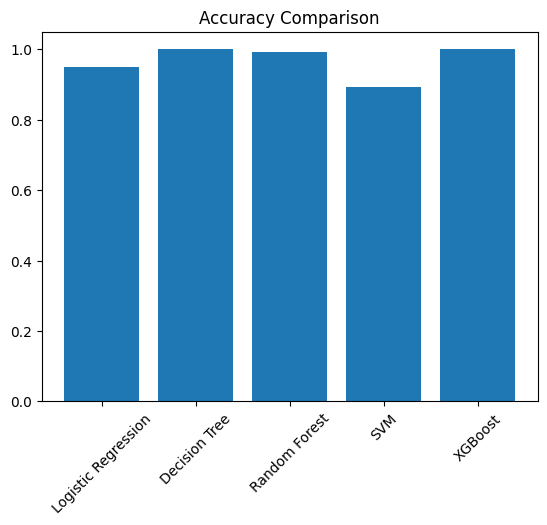

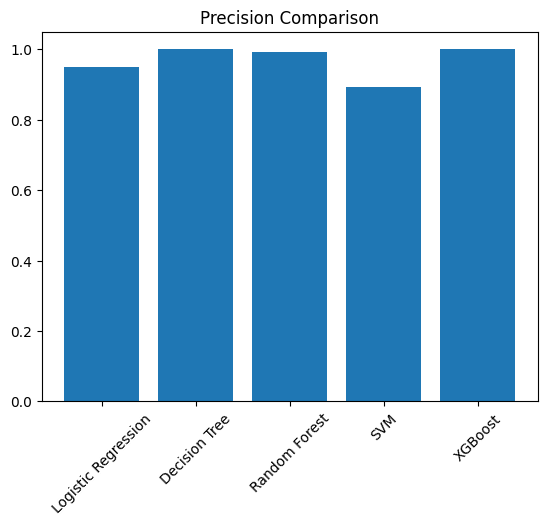

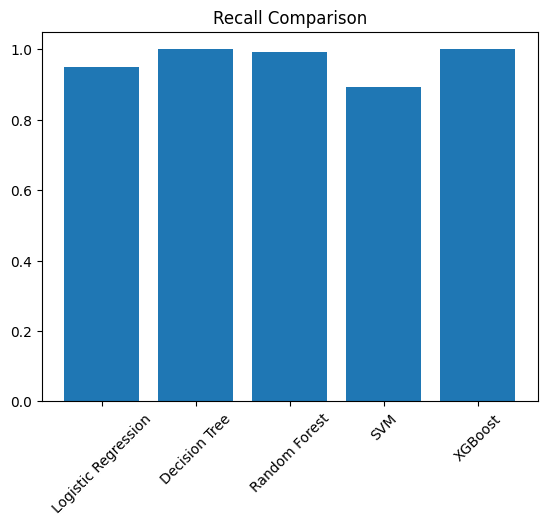

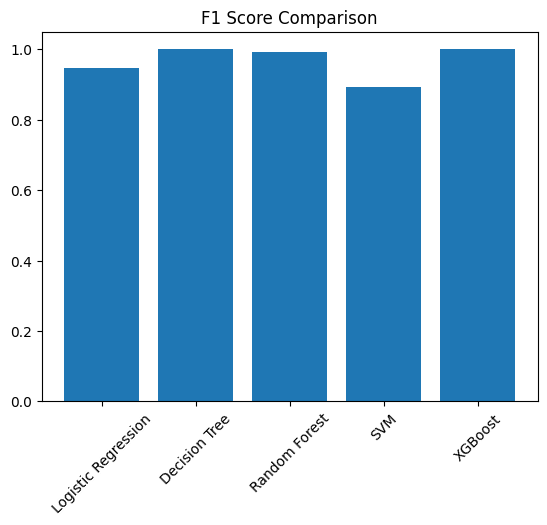

In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_names = []
accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

for name, pred in models_pred.items():
    model_names.append(name)
    accuracy_list.append(accuracy_score(y_test, pred))
    precision_list.append(precision_score(y_test, pred, average='weighted'))
    recall_list.append(recall_score(y_test, pred, average='weighted'))
    f1_list.append(f1_score(y_test, pred, average='weighted'))

x = np.arange(len(model_names))

plt.figure()
plt.bar(x, accuracy_list)
plt.xticks(x, model_names, rotation=45)
plt.title("Accuracy Comparison")
plt.show()

plt.figure()
plt.bar(x, precision_list)
plt.xticks(x, model_names, rotation=45)
plt.title("Precision Comparison")
plt.show()

plt.figure()
plt.bar(x, recall_list)
plt.xticks(x, model_names, rotation=45)
plt.title("Recall Comparison")
plt.show()

plt.figure()
plt.bar(x, f1_list)
plt.xticks(x, model_names, rotation=45)
plt.title("F1 Score Comparison")
plt.show()

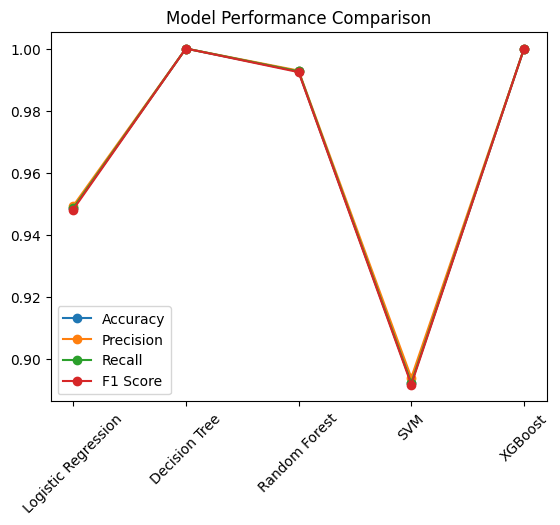

In [37]:
plt.figure()

plt.plot(model_names, accuracy_list, marker='o', label='Accuracy')
plt.plot(model_names, precision_list, marker='o', label='Precision')
plt.plot(model_names, recall_list, marker='o', label='Recall')
plt.plot(model_names, f1_list, marker='o', label='F1 Score')

plt.xticks(rotation=45)
plt.title("Model Performance Comparison")
plt.legend()
plt.show()

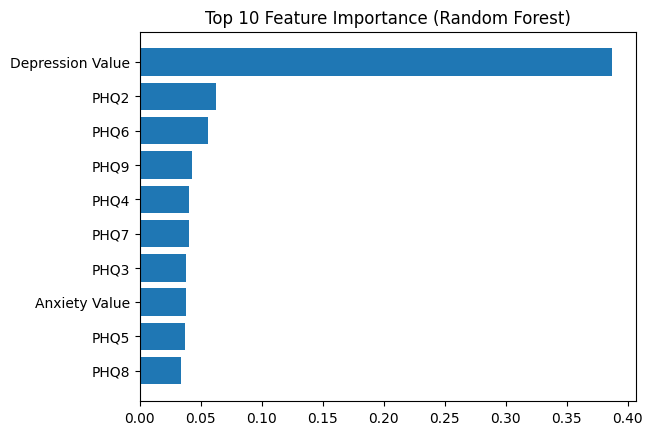

In [38]:
importance = model_rf.feature_importances_
features = X.columns

indices = np.argsort(importance)[-10:]

plt.figure()
plt.barh(range(len(indices)), importance[indices])
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title("Top 10 Feature Importance (Random Forest)")
plt.show()

In [42]:
metrics_df.to_csv('/content/drive/MyDrive/model_results.csv', index=False)